## Naseem Saleh
## INST414
## Module 6 Assignment¶
## November 21, 2025

dataset source:
https://data.montgomerycountymd.gov/Public-Safety/Crash-Reporting-Non-Motorists-Data/n7fk-dce5/about_data

Question - The stakeholder would be this person who is commonly a pedestrian. Decide if a supervised learning model can accurately identify the severity and if the model would be reliable enough to be used to find which roadways are riskier.

In [94]:
import pandas as pd

from sklearn.metrics import DistanceMetric, pairwise_distances

import matplotlib.pyplot as plt

In [95]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.tree import DecisionTreeClassifier

import matplotlib.pyplot as plt

In [351]:
crash_df = pd.read_csv("Crash_Reporting_-_Non-Motorists_Data_20251202.csv")
print("Crash Reporting DF Rows:", len(crash_df))

Crash Reporting DF Rows: 6984


## Data Cleaning

In [352]:
#Checking first few rows of the data:
crash_df.head()

,Report Number,Local Case Number,Agency Name,ACRS Report Type,Crash Date/Time,Route Type,Road Name,Cross-Street Name,Off-Road Description,Municipality,...,Pedestrian Type,Pedestrian Movement,Pedestrian Actions,Pedestrian Location,At Fault,Injury Severity,Safety Equipment,Latitude,Longitude,Location
0,EJ7898007G,250052765,GAITHERSBURG,Injury Crash,11/24/2025 04:50:00 PM,Maryland (State) Route,FREDERICK RD,NaN,NaN,NaN,...,Pedestrian,Cross/Enter Not at Intersection,Dart/Dash,Travel Lane Other Location,Yes,Suspected Serious Injury,NaN,39.150658,-77.209529,"(39.15065762, -77.20952904)"
1,MCP2099000F,250052650,MONTGOMERY,Injury Crash,11/24/2025 07:55:00 AM,County Route,URBANA DR,GEORGIA AVE,NaN,NaN,...,Pedestrian,Cross/Enter at Intersection,None (No Improper Action),Intersection Marked Crosswalk,No,Suspected Minor Injury,NaN,39.061461,-77.052485,"(39.0614609, -77.05248537)"
2,MCP32330060,250052582,MONTGOMERY,Injury Crash,11/23/2025 03:22:00 PM,County Route,CARROLL AVE,NaN,NaN,NaN,...,Scooter (electric),Walking/Cycling on Sidewalk,Improper Turn/Merge),Sidewalk,Yes,Suspected Minor Injury,NaN,38.999010,-76.991110,"(38.99901034, -76.99111048)"
3,MCP289200JQ,250052482,MONTGOMERY,Injury Crash,11/22/2025 07:04:00 PM,County Route,TILTON DR,NaN,NaN,NaN,...,Pedestrian,Cross/Enter at Intersection,"Not Visible (Dark Clothing, No Lighting, etc.)",Intersection Unmarked Crosswalk,No,Suspected Minor Injury,NaN,39.018403,-77.043627,"(39.0184028, -77.04362734)"
4,EJ78950082,250052478,GAITHERSBURG,Injury Crash,11/22/2025 06:30:00 PM,NaN,NaN,NaN,Parking Lot Way PARKING LOT OF 221 MUDD...,NaN,...,Pedestrian,Standing,None (No Improper Action),Other,No,Possible Injury,NaN,39.128188,-77.205960,"(39.1281875, -77.20596)"


In [353]:
#Checking info about the data:
crash_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6984 entries, 0 to 6983
Data columns (total 29 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Report Number                 6984 non-null   object 
 1   Local Case Number             6984 non-null   int64  
 2   Agency Name                   6984 non-null   object 
 3   ACRS Report Type              6984 non-null   object 
 4   Crash Date/Time               6984 non-null   object 
 5   Route Type                    5414 non-null   object 
 6   Road Name                     5335 non-null   object 
 7   Cross-Street Name             4936 non-null   object 
 8   Off-Road Description          1496 non-null   object 
 9   Municipality                  624 non-null    object 
 10  Related Non-Motorist          6984 non-null   object 
 11  Collision Type                6806 non-null   object 
 12  Weather                       6526 non-null   object 
 13  Sur

In [354]:
crash_df.isnull().sum() #Checking null values

Report Number                      0
Local Case Number                  0
Agency Name                        0
ACRS Report Type                   0
Crash Date/Time                    0
Route Type                      1570
Road Name                       1649
Cross-Street Name               2048
Off-Road Description            5488
Municipality                    6360
Related Non-Motorist               0
Collision Type                   178
Weather                          458
Surface Condition               1655
Light                             46
Traffic Control                 1064
Driver Substance Abuse          1097
Non-Motorist Substance Abuse    1203
Person ID                          0
Pedestrian Type                    0
Pedestrian Movement              207
Pedestrian Actions               294
Pedestrian Location              153
At Fault                         287
Injury Severity                    0
Safety Equipment                3020
Latitude                           0
L

In [355]:
#Getting only the columns wanted for the model:
crash_df = crash_df[["Crash Date/Time",
             "Route Type", "Weather", 
             "Surface Condition", "Light", 
             "Traffic Control", "Driver Substance Abuse",
             "Pedestrian Movement",
             "Pedestrian Location",
             "Injury Severity", "Safety Equipment"]]

#Attempting to fill any N/As with Unknown:
crash_df.fillna("Unknown")

#Checking the column value names to see if there are any repeated values:

col_names = ["Crash Date/Time",
             "Route Type", "Weather", 
             "Surface Condition", "Light", 
             "Traffic Control", "Driver Substance Abuse",
             "Pedestrian Movement",
             "Pedestrian Location",
             "Injury Severity", "Safety Equipment"]

for i in col_names:
    print(i, crash_df[i].unique())

#Variances in capitalization and wording

Crash Date/Time ['11/24/2025 04:50:00 PM' '11/24/2025 07:55:00 AM'
 '11/23/2025 03:22:00 PM' ... '01/03/2015 08:31:00 PM'
 '01/02/2015 11:51:00 AM' '01/01/2015 06:00:00 PM']
Route Type ['Maryland (State) Route' 'County Route' nan 'Bicycle Route' 'Local Route'
 'Municipality Route' 'Other Public Roadway' 'Government Route'
 'US (State)' 'Crossover' 'Spur' 'Service Road' 'Ramp' 'Private Route'
 'Interstate (State)' 'Municipality' 'County' 'Maryland (State)'
 'Government']
Weather ['Clear' 'Cloudy' 'Rain' 'Unknown' 'Fog, Smog, Smoke'
 'Freezing Rain Or Freezing Drizzle' 'Snow' 'Blowing Snow' 'CLEAR'
 'RAINING' 'CLOUDY' nan 'FOGGY' 'UNKNOWN' 'OTHER' 'WINTRY MIX' 'SNOW'
 'SEVERE WINDS' 'SLEET' 'BLOWING SNOW']
Surface Condition ['Dry' nan 'Wet' 'Ice/Frost' 'Slush' 'Snow' 'Other' 'DRY' 'WET' 'UNKNOWN'
 'SNOW' 'SLUSH' 'ICE' 'OTHER']
Light ['Dark - Lighted' 'Daylight' 'Dark - Unknown Lighting'
 'Dark - Not Lighted' 'Dusk' 'Dawn' 'Unknown' 'Other' 'DARK LIGHTS ON'
 'DAYLIGHT' 'DARK NO LIGHTS' 'D

In [356]:
#Rename values vals for minor injury, possible injury? and no apparent injury  into  low-risk  and all others high risk
# and / or turn into 1 and 0  p

#Making all values uppercase to remove inconsistencies:
crash_df["Weather"] = crash_df["Weather"].apply(lambda x: str(x).upper())

#Counting the recorded points of weather for each value:
print(crash_df["Weather"].value_counts())


Weather
CLEAR                                5007
CLOUDY                                642
RAINING                               601
NAN                                   458
RAIN                                  130
UNKNOWN                                44
SNOW                                   37
FOGGY                                  22
OTHER                                  12
WINTRY MIX                             11
SEVERE WINDS                            7
BLOWING SNOW                            6
SLEET                                   3
FREEZING RAIN OR FREEZING DRIZZLE       2
FOG, SMOG, SMOKE                        2
Name: count, dtype: int64


In [357]:
crash_df["Weather"] = crash_df["Weather"].replace({
    "BLOWING SNOW": "SNOW", "RAINING": "RAIN", "FOG, SMOG, SMOKE": "FOGGY", "NAN": "UNKNOWN",
    "SNOW": "COLD/STRONG WEATHER/BAD VISIBILITY", "FOGGY": "COLD/STRONG WEATHER/BAD VISIBILITY", 
    "WINTRY MIX": "COLD/STRONG WEATHER/BAD VISIBILITY", "SLEET": "COLD/STRONG WEATHER/BAD VISIBILITY", 
    "FREEZING RAIN OR FREEZING DRIZZLE": "COLD/STRONG WEATHER/BAD VISIBILITY", "OTHER": "COLD/STRONG WEATHER/BAD VISIBILITY",
    "SEVERE WINDS": "COLD/STRONG WEATHER/BAD VISIBILITY"}) 

print("\n", crash_df["Weather"].value_counts())

print(crash_df["Weather"].unique())


 Weather
CLEAR                                 5007
RAIN                                   731
CLOUDY                                 642
UNKNOWN                                502
COLD/STRONG WEATHER/BAD VISIBILITY      94
SNOW                                     6
FOGGY                                    2
Name: count, dtype: int64
['CLEAR' 'CLOUDY' 'RAIN' 'UNKNOWN' 'FOGGY'
 'COLD/STRONG WEATHER/BAD VISIBILITY' 'SNOW']


In [358]:
#Checking Surface Condition values and cleaning:

crash_df["Surface Condition"] = crash_df["Surface Condition"].apply(lambda x: str(x).upper())

print(crash_df["Surface Condition"].value_counts())

crash_df["Surface Condition"] = crash_df["Surface Condition"].replace({
    "NAN": "OTHER/UNKNOWN", "ICE": "WINTRY MIX", "ICE/FROST": "WINTRY MIX",
    "UNKNOWN": "OTHER/UNKNOWN", "OTHER": "OTHER/UNKNOWN", "SNOW": "WINTRY MIX", "SLUSH": "WINTRY MIX"}) 

print("\n", crash_df["Surface Condition"].value_counts())

print(crash_df["Surface Condition"].unique())

Surface Condition
DRY          4419
NAN          1655
WET           838
UNKNOWN        25
SNOW           18
ICE            11
SLUSH           7
OTHER           6
ICE/FROST       5
Name: count, dtype: int64

 Surface Condition
DRY              4419
OTHER/UNKNOWN    1686
WET               838
WINTRY MIX         41
Name: count, dtype: int64
['DRY' 'OTHER/UNKNOWN' 'WET' 'WINTRY MIX']


In [359]:
#Checking lighting values and cleaning:

crash_df["Light"] = crash_df["Light"].apply(lambda x: str(x).upper())

print(crash_df["Light"].value_counts())

crash_df["Light"] = crash_df["Light"].replace({
    "DARK -- UNKNOWN LIGHTING": "DARK - UNKNOWN LIGHTING", 
    "DARK NO LIGHTS": "DARK - NOT LIGHTED", 
    "DARK LIGHTS ON": "DARK - LIGHTED", 
    "NAN": "OTHER/UNKNOWN", "OTHER": "OTHER/UNKNOWN", "UNKNOWN": "OTHER/UNKNOWN"}) 

print("\n", crash_df["Light"].value_counts())

print(crash_df["Light"].unique())

Light
DAYLIGHT                    4524
DARK LIGHTS ON              1456
DARK - LIGHTED               279
DARK NO LIGHTS               211
DUSK                         151
DAWN                         124
DARK -- UNKNOWN LIGHTING      68
DARK - NOT LIGHTED            60
NAN                           46
UNKNOWN                       27
OTHER                         21
DARK - UNKNOWN LIGHTING       17
Name: count, dtype: int64

 Light
DAYLIGHT                   4524
DARK - LIGHTED             1735
DARK - NOT LIGHTED          271
DUSK                        151
DAWN                        124
OTHER/UNKNOWN                94
DARK - UNKNOWN LIGHTING      85
Name: count, dtype: int64
['DARK - LIGHTED' 'DAYLIGHT' 'DARK - UNKNOWN LIGHTING'
 'DARK - NOT LIGHTED' 'DUSK' 'DAWN' 'OTHER/UNKNOWN']


In [360]:
#Checking Traffic Control column values:

crash_df["Traffic Control"] = crash_df["Traffic Control"].apply(lambda x: str(x).title())

crash_df["Traffic Control"] = crash_df["Traffic Control"].replace({
    "Flashing Railroad Crossing Signal (May Include Gates)": "Railway Crossing Device", "Nan": "Unknown", 
    "Person (Including Flagger, Law Enforcement, Crossing Guard, Etc.": "Person",
    "Pedestrian Crossing Sign": "Pedestrian Crossing", 
    "Traffic Control Signal": "Traffic Signal", 
    "Flashing Traffic Control Signal": "Flashing Traffic Signal", "Other Warning Sign": "Warning Sign"} ) 

#Putting categories/values together further. Rare Control for more uncommon controls, warning sign for warnings,  other/unknown.
crash_df["Traffic Control"] = crash_df["Traffic Control"].replace({
    "Unknown": "Other/Unknown", "Other": "Other/Unknown", 
    "Intersection Ahead Warning Sign": "Warning Sign", 
    "Curve Ahead Warning Sign": "Warning Sign",
    "School Zone Sign Device": "Warning Sign", "Bicycle Crossing Sign": "Warning Sign", 
    "Railway Crossing Device": "Rare Control", "Other Pavement Marking (Excluding Edgelines, Centerlines, Or Lane Lines)": "Rare Control",
    "Flashing Traffic Signal": "Rare Control", "Lane Use Control Signal": "Rare Control",
    "Person": "Rare Control", "Yield Sign": "Rare Control"
}) 

#Counting to make sure the values are okay amounts
print(crash_df["Traffic Control"].value_counts())

print(crash_df["Traffic Control"].unique())

Traffic Control
No Controls            2676
Traffic Signal         2010
Other/Unknown          1259
Stop Sign               723
Rare Control            152
Pedestrian Crossing     136
Warning Sign             28
Name: count, dtype: int64
['Traffic Signal' 'No Controls' 'Other/Unknown' 'Stop Sign' 'Rare Control'
 'Pedestrian Crossing' 'Warning Sign']


In [361]:
#Checking Driver Substance Abuse column values
crash_df["Driver Substance Abuse"] = crash_df["Driver Substance Abuse"].apply(lambda x: str(x).title())

print(crash_df["Driver Substance Abuse"].value_counts())

print(crash_df["Driver Substance Abuse"].unique())

Driver Substance Abuse
None Detected                                                                                                                 3776
Nan                                                                                                                           1097
Not Suspect Of Alcohol Use, Not Suspect Of Drug Use                                                                           1033
Unknown                                                                                                                        687
Unknown, Unknown                                                                                                               232
Alcohol Present                                                                                                                 47
Not Suspect Of Alcohol Use, Not Suspect Of Drug Use, Not Suspect Of Alcohol Use, Not Suspect Of Drug Use                        22
Alcohol Contributed                                         

In [362]:

#Cleaning the values, putting together repeated ones, Normally not suspect will be none detected, 
#though I put Unknown for "Not suspect of alcohol use, unknown". I interpret this as a possible list of drivers involved and substance detection.
#Unknown after alcohol likely is a placeholder drug use. Pattern: Always alcohol first then drug, alcohol, drug.
#Drugs/Medicene put together, although despite few small datapoints drug contributed, put as drug possible since some did contribute,
#and it might be possible for the other types to also contribute (such as medicene being present). Not enough information to be sure.

crash_df["Driver Substance Abuse"] = crash_df["Driver Substance Abuse"].replace({
    "Nan": "Unknown", "N/A, None Detected": "Unknown", 
    "Unknown, Unknown": "Unknown", 
    "None Detected, Unknown": "Unknown", 
    "Not Suspect Of Alcohol Use, Not Suspect Of Drug Use": "None Detected", 
    "Not Suspect Of Alcohol Use, Not Suspect Of Drug Use, Not Suspect Of Alcohol Use, Not Suspect Of Drug Use": "None Detected", 
    "Unknown, Unknown, Unknown, Unknown" : "Unknown", 
    
    "Alcohol Contributed, None Detected": "Alcohol Possible", 
    "Alcohol Present, None Detected": "Alcohol Possible", 
    "Alcohol Present, Unknown": "Alcohol Possible", 
    "Not Suspect Of Alcohol Use, Not Suspect Of Drug Use, Unknown, Not Suspect Of Drug Use": "None Detected", 
    
    "Suspect Of Alcohol Use, Not Suspect Of Drug Use": "Alcohol Possible",
    "Alcohol Present, N/A": "Alcohol Possible",
    "Not Suspect Of Alcohol Use, Not Suspect Of Drug Use, Not Suspect Of Alcohol Use, Not Suspect Of Drug Use, Unknown, Unknown": "None Detected", 
    "Not Suspect Of Alcohol Use, Unknown": "Unknown",
    "Illegal Drug Present": "Drug Possible",
    
    "Illegal Drug Contributed": "Drug Possible", "Medication Present": "Drug Possible", 
    "Combined Substance Present, None Detected": "Drug Possible",  "Combined Substance Present": "Drug Possible",
    "Medication Present, None Detected": "Drug Possible", 
    
    "Alcohol Contributed, N/A": "Alcohol Possible",
    "Suspect Of Alcohol Use, Unknown": "Alcohol Possible", 
    "Not Suspect Of Alcohol Use, Not Suspect Of Drug Use, Unknown, Unknown": "None Detected",
    "Alcohol Present": "Alcohol Possible", "Alcohol Contributed": "Alcohol Possible",
    "Other": "Unknown", }) 


print(crash_df["Driver Substance Abuse"].value_counts())

print(crash_df["Driver Substance Abuse"].unique())

Driver Substance Abuse
None Detected       4844
Unknown             2039
Alcohol Possible      90
Drug Possible         11
Name: count, dtype: int64
['None Detected' 'Unknown' 'Alcohol Possible' 'Drug Possible']


 "Nan": "Unknown", "N/A, None Detected": "Unknown", 
    "Unknown, Unknown": "Unknown", 
    "None Detected, Unknown": "Unknown", 
    "Not Suspect Of Alcohol Use, Not Suspect Of Drug Use": "None Detected", 
    "Not Suspect Of Alcohol Use, Not Suspect Of Drug Use, Not Suspect Of Alcohol Use, Not Suspect Of Drug Use": "None Detected", 
    "Unknown, Unknown, Unknown, Unknown" : "Unknown", 
    
    "Alcohol Contributed, None Detected": "Alcohol Contributed", 
    "Alcohol Present, None Detected": "Alcohol Present", 
    "Alcohol Present, Unknown": "Alcohol Present", 
    "Not Suspect Of Alcohol Use, Not Suspect Of Drug Use, Unknown, Not Suspect Of Drug Use": "None Detected", 
    
    "Suspect Of Alcohol Use, Not Suspect Of Drug Use": "Alcohol Contributed",
    "Alcohol Present, N/A": "Alcohol Present",
    "Not Suspect Of Alcohol Use, Not Suspect Of Drug Use, Not Suspect Of Alcohol Use, Not Suspect Of Drug Use, Unknown, Unknown": "None Detected", 
    "Not Suspect Of Alcohol Use, Unknown": "Unknown",
    "Illegal Drug Present": "Drug Possible",
    
    "Illegal Drug Contributed": "Drug Possible", "Medication Present": "Drug Possible", 
    "Combined Substance Present, None Detected": "Drug Possible",  "Combined Substance Present": "Drug Possible",
    "Medication Present, None Detected": "Drug Possible", 
    
    "Alcohol Contributed, N/A": "Alcohol Contributed",
    "Suspect Of Alcohol Use, Unknown": "Alcohol Contributed", 
    "Not Suspect Of Alcohol Use, Not Suspect Of Drug Use, Unknown, Unknown": "None Detected",
    "Other": "Unknown", "Alcohol Present": "Alcohol", "Alcohol Contributed": "Alcohol"}) 

In [363]:
#Checking Pedestrian Movement column values:

crash_df["Pedestrian Movement"] = crash_df["Pedestrian Movement"].apply(lambda x: str(x).title())

print(crash_df["Pedestrian Movement"].value_counts())

print(crash_df["Pedestrian Movement"].unique())

Pedestrian Movement
Cross/Enter At Intersection                                                      3094
Other                                                                             862
Cross/Enter Not At Intersection                                                   826
Standing                                                                          463
Walking/Riding W/Traffic                                                          387
Walking/Cycling On Sidewalk                                                       369
Nan                                                                               207
Unknown                                                                           139
Other Working                                                                     118
Getting Off/On Vehicle                                                            113
Walking/Riding Against Traffic                                                    113
Walking/Cycling Along Roadway With

In [364]:
#Cleaning Pedestrian Movement column values

crash_df["Pedestrian Movement"] = crash_df["Pedestrian Movement"].replace({ 
    "Nan": "Unknown", "Push/Work On Vehicle": "Push/Work On Vehicle/Other", "Other Working": "Push/Work On Vehicle/Other", "Walking To/From School": "SchoolBus/ToFromSchool/Playing",
    "Approach/Leaving Schoolbus": "SchoolBus/ToFromSchool/Playing",
    "Playing": "SchoolBus/ToFromSchool/Playing", "Hitchhiking": "Getting Off/On Vehicle",
    "Walking/Cycling Along Roadway Against Traffic (In Or Adjacent To Travel Lane)": "Walking/Riding Against Traffic",
    "Walking/Cycling Along Roadway With Traffic (In Or Adjacent To Travel Lane)": "Walking/Riding W/Traffic", 
    
})

print(crash_df["Pedestrian Movement"].value_counts())

Pedestrian Movement
Cross/Enter At Intersection        3094
Other                               862
Cross/Enter Not At Intersection     826
Walking/Riding W/Traffic            481
Standing                            463
Walking/Cycling On Sidewalk         369
Unknown                             346
Walking/Riding Against Traffic      147
Push/Work On Vehicle/Other          147
SchoolBus/ToFromSchool/Playing      133
Getting Off/On Vehicle              116
Name: count, dtype: int64


In [365]:
#Checking pedestrian location column values
crash_df["Pedestrian Location"] = crash_df["Pedestrian Location"].apply(lambda x: str(x).title())

print(crash_df["Pedestrian Location"].value_counts())

print(crash_df["Pedestrian Location"].unique())

Pedestrian Location
On Roadway At Crosswalk             1503
Other                               1175
On Roadway Not At Crosswalk         1170
At Intersection Marked Crosswalk     664
Intersection Marked Crosswalk        523
Sidewalk                             449
At Intersection But No Crosswalk     246
Travel Lane Other Location           180
Nan                                  153
Shoulder                             143
Unknown                               80
Intersection Unmarked Crosswalk       77
Driveway Access                       71
Outside Right Of Way                  65
Curb                                  65
Inside Building                       63
Intersection Other                    60
Shoulder/Roadside                     56
Driveway Access Marked Crosswalk      51
In Bikeway                            43
Midblock Marked Crosswalk             39
Nontrafficway Area                    31
Median                                27
Onstreet Bike Lanes                  

In [366]:
#  "Nan": "Unknown", 
# "Curb": "Sidewalk", "Shoulder": "Shoulder/Roadside", 
#    "Island": "Median/Crossing Island", "Median": "Median/Crossing Island",

crash_df["Pedestrian Location"] = crash_df["Pedestrian Location"].replace({
    "At Intersection Marked Crosswalk": "Intersection Marked Crosswalk", 
    "At Intersection But No Crosswalk": "Intersection Unmarked Crosswalk",
    "Nan": "Unknown", 
    "Curb": "Sidewalk", "Shoulder": "Shoulder/Bike Lanes/Trail",  "Shoulder/Roadside": "Shoulder/Bike Lanes/Trail",
    "Island": "Midblock Crossing/Travel Lane Other/Median", "Median": "Midblock Crossing/Travel Lane Other/Median",
    "Shared Lane Markings)": "Shoulder/Bike Lanes/Trail", "Onstreet Buffered Bike Lanes": "Shoulder/Bike Lanes/Trail",
    
    "In Bikeway": "Shoulder/Bike Lanes/Trail", "Shared Use Path Or Trails": "Shoulder/Bike Lanes/Trail", 
    "Shared Use Paths or Trails": "Shoulder/Bike Lanes/Trail",
    "Seperated Bike Lanes": "Shoulder/Bike Lanes/Trail", 
    "Shared Use Path Or Trail": "Shoulder/Bike Lanes/Trail", 
    
    "Travel Lane Other Location": "Midblock Crossing/Travel Lane Other/Median", 
    "Midblock Marked Crosswalk": "Midblock Crossing/Travel Lane Other/Median",
    "Offstreet Trails Or Sidepaths": "Shoulder/Bike Lanes/Trail", 
    "Intersection Other": "Intersection Unmarked Crosswalk",
    "Separated Bike Lanes": "Shoulder/Bike Lanes/Trail", 
    
    "Onstreet Bike Lanes": "Shoulder/Bike Lanes/Trail", "Median/Crossing Island": "Midblock Crossing/Travel Lane Other/Median",
    "Nontrafficway Area" : "Other", "Inside Building": "Other", 
    "In School Bus Zone": "Other", 
    "Shoulder/Roadside": "Shoulder/Bike Lanes/Trail",
    "Outside Right Of Way" : "Other",
    "Driveway Access" : "Driveway Access/Crosswalk", "Driveway Access Marked Crosswalk": "Driveway Access/Crosswalk"

})


print(crash_df["Pedestrian Location"].value_counts())


Pedestrian Location
On Roadway At Crosswalk                       1503
Other                                         1337
Intersection Marked Crosswalk                 1187
On Roadway Not At Crosswalk                   1170
Sidewalk                                       514
Intersection Unmarked Crosswalk                383
Shoulder/Bike Lanes/Trail                      282
Midblock Crossing/Travel Lane Other/Median     253
Unknown                                        233
Driveway Access/Crosswalk                      122
Name: count, dtype: int64



crash_df["Pedestrian Location"] = crash_df["Pedestrian Location"].replace({
    "At Intersection Marked Crosswalk": "Intersection Marked Crosswalk", 
    "At Intersection But No Crosswalk": "Intersection Unmarked Crosswalk",
    "Nan": "Unknown", 
    "Curb": "Sidewalk", "Shoulder": "Shoulder/Roadside", 
    "Island": "Midblock Crossing/Travel Lane Other/Median", "Median": "Midblock Crossing/Travel Lane Other/Median",
    "Shared Lane Markings)": "Shoulder/Bike Lanes/Trail", "Onstreet Buffered Bike Lanes": "Shoulder/Bike Lanes/Trail",
    
    "In Bikeway": "Shoulder/Bike Lanes/Trail", "Shared Use Path Or Trails": "Shoulder/Bike Lanes/Trail", 
    "Shared Use Paths or Trails": "Shoulder/Bike Lanes/Trail",
    "Seperated Bike Lanes": "Shoulder/Bike Lanes/Trail", 
    "Shared Use Path Or Trail": "Shoulder/Bike Lanes/Trail", 
    
    "Travel Lane Other Location": "Midblock Crossing/Travel Lane Other/Median", 
    "Midblock Marked Crosswalk": "Midblock Crossing/Travel Lane Other/Median",
    "Offstreet Trails Or Sidepaths": "Shoulder/Bike Lanes/Trail", 
    "Intersection Other": "Intersection Unmarked Crosswalk",
    "Separated Bike Lanes": "Shoulder/Bike Lanes/Trail", 
    
    "Onstreet Bike Lanes": "Shoulder/Bike Lanes/Trail", "Median/Crossing Island": "Midblock Crossing/Travel Lane Other/Median",
    "Nontrafficway Area" : "Rare or Off-Road Locations", "Inside Building": "Rare or Off-Road Locations", 
    "In School Bus Zone": "Rare or Off-Road Locations", 
    "Shoulder/Roadside": "Shoulder/Bike Lanes/Trail",
    "Outside Right Of Way" : "Rare or Off-Road Locations",
    "Rare or Off-Road Locations": "Other",
    "Driveway Access" : "Driveway Access/Crosswalk", "Driveway Access Marked Crosswalk": "Driveway Access/Crosswalk"

})

Had rare or off-road locations name before


In [367]:
crash_df["Injury Severity"] = crash_df["Injury Severity"].apply(lambda x: str(x).title())

print(crash_df["Injury Severity"].value_counts())

Injury Severity
Suspected Minor Injury      3180
Possible Injury             2168
Suspected Serious Injury     778
No Apparent Injury           704
Fatal Injury                 154
Name: count, dtype: int64


In [368]:
crash_df["Injury Severity"] = crash_df["Injury Severity"].replace({
    "Suspected Minor Injury": "Low Severity", "Possible Injury": "Low Severity",
    "No Apparent Injury": "Low Severity", "Fatal Injury": "High Severity",
    "Suspected Serious Injury": "High Severity"                                                               
})

print(crash_df["Injury Severity"].value_counts())

#Indicates a severe data imbalance:

Injury Severity
Low Severity     6052
High Severity     932
Name: count, dtype: int64


In [ ]:
#Checking Safety Equipment column values
print(crash_df["Safety Equipment"].unique())

In [369]:
#Changing the formatting to match everything (in case of repeats with different capitalizations)
crash_df["Safety Equipment"] = crash_df["Safety Equipment"].apply(lambda x: str(x).title())

print(crash_df["Safety Equipment"].unique())

['Nan' 'Unknown' 'Helmet, Lighting, Reflectors' 'Helmet'
 'Helmet, Reflectors'
 'Helmet, Reflective Wear (Backpack, Triangles, Etc.)'
 'Helmet, Protective Pads (Elbows, Knees, Shins, Etc.), Reflectors'
 'Helmet, Protective Pads (Elbows, Knees, Shins, Etc.)'
 'Reflective Wear (Backpack, Triangles, Etc.)' 'Other'
 'Helmet, Other, Reflectors'
 'Helmet, Lighting, Protective Pads (Elbows, Knees, Shins, Etc.)'
 'Helmet, Lighting, Protective Pads (Elbows, Knees, Shins, Etc.), Reflective Wear (Backpack, Triangles, Etc.)'
 'Helmet, Other' 'Lighting, Reflective Wear (Backpack, Triangles, Etc.)'
 'Helmet, Lighting'
 'Helmet, Lighting, Protective Pads (Elbows, Knees, Shins, Etc.), Reflectors'
 'Reflectors' 'None, Other'
 'Helmet, Reflective Wear (Backpack, Triangles, Etc.), Reflectors'
 'Lighting'
 'Helmet, Lighting, Reflective Wear (Backpack, Triangles, Etc.), Reflectors'
 'Helmet, Lighting, Reflective Wear (Backpack, Triangles, Etc.)' 'None'
 'Mc/Bike Helmet' 'Reflective Clothing' 'Protective Pa

In [370]:
#Checking the number of values:
print(crash_df["Safety Equipment"].value_counts())

Safety Equipment
Nan                                                                                                            3020
None                                                                                                           2862
Mc/Bike Helmet                                                                                                  615
Unknown                                                                                                         177
Helmet                                                                                                          108
Reflective Clothing                                                                                             104
Other                                                                                                            29
Lighting                                                                                                         14
Reflective Wear (Backpack, Triangles, Etc.)            

In [371]:
#Cleaning up the Safety Equipment column:

crash_df["Safety Equipment"] = crash_df["Safety Equipment"].replace({ 
    "Mc/Bike Helmet": "Helmet", "Reflective Wear (Backpack, Triangles, Etc.)": "Reflective", "Reflective Clothing":"Reflective", 
    "Reflectors":"Reflective", "Lighting": "Reflective", 
    "Nan": "Unknown", 
    "Lighting, Reflective Wear (Backpack, Triangles, Etc.)": "Reflective",
    
    "Helmet, Reflective Wear (Backpack, Triangles, Etc.), Reflectors": "Helmet/Protection/Reflective/Other",
    "Helmet, Protective Pads (Elbows, Knees, Shins, Etc.)": "Helmet/Protection/Reflective/Other",
    
    "Helmet, Reflective Wear (Backpack, Triangles, Etc.)": "Helmet/Protection/Reflective/Other", 
    "Helmet, Lighting, Protective Pads (Elbows, Knees, Shins, Etc.), Reflective Wear (Backpack, Triangles, Etc.)": "Helmet/Protection/Reflective/Other",
    "Helmet, Lighting, Reflective Wear (Backpack, Triangles, Etc.), Reflectors" : "Helmet/Protection/Reflective/Other",
    
    "Helmet, Lighting, Reflective Wear (Backpack, Triangles, Etc.)" : "Helmet/Protection/Reflective/Other",
    
    "Helmet, Reflectors": "Helmet/Protection/Reflective/Other", 
    "Helmet, Lighting, Reflectors": "Helmet/Protection/Reflective/Other",
    "Helmet, Lighting": "Helmet/Protection/Reflective/Other", 
    "Helmet, Other, Reflectors" : "Helmet/Protection/Reflective/Other",
    "Helmet, Lighting, Protective Pads (Elbows, Knees, Shins, Etc.)": "Helmet/Protection/Reflective/Other",
    "Helmet, Lighting, Protective Pads (Elbows, Knees, Shins, Etc.), Reflectors": "Helmet/Protection/Reflective/Other", 
    "Helmet, Reflective Wear (Backpack, Triangles, Etc.), Reflectors": "Helmet/Protection/Reflective/Other",
    "Helmet, Protective Pads (Elbows, Knees, Shins, Etc.), Reflectors" : "Helmet/Protection/Reflective/Other",
    "Protective Pads": "Helmet/Protection/Reflective/Other",
    "Helmet, Other": "Helmet/Protection/Reflective/Other", "Helmet": "Helmet/Protection/Reflective/Other", "None, Other": "Other",
    
})
print(crash_df["Safety Equipment"].value_counts())


Safety Equipment
Unknown                               3197
None                                  2862
Helmet                                 615
Helmet/Protection/Reflective/Other     146
Reflective                             133
Other                                   31
Name: count, dtype: int64


In [372]:
#Checking Crash Date/Time rows and data type:
crash_df["Crash Date/Time"].head()

0    11/24/2025 04:50:00 PM
1    11/24/2025 07:55:00 AM
2    11/23/2025 03:22:00 PM
3    11/22/2025 07:04:00 PM
4    11/22/2025 06:30:00 PM
Name: Crash Date/Time, dtype: object

In [373]:
#crash_df["Crash Date/Time"] = crash_df["Crash Date/Time"].strftime(crash_df["Crash Date/Time"], format="%m/%d/%Y %I:%M:%S %p")

In [374]:
#Converting the date/time column into the date/time value instead of a string object.
crash_df["Crash Date/Time"] = pd.to_datetime(crash_df["Crash Date/Time"], format="%m/%d/%Y %I:%M:%S %p")

In [376]:
#Confirming it worked:
crash_df["Crash Date/Time"].head()

0   2025-11-24 16:50:00
1   2025-11-24 07:55:00
2   2025-11-23 15:22:00
3   2025-11-22 19:04:00
4   2025-11-22 18:30:00
Name: Crash Date/Time, dtype: datetime64[ns]

In [378]:
#Getting the week days, time of day, and month from the date/time:
crash_df["Time of Day"] = crash_df["Crash Date/Time"].dt.hour
crash_df["Week Day"] = crash_df["Crash Date/Time"].dt.day_name()
crash_df["Month"] = crash_df["Crash Date/Time"].dt.month

print(crash_df["Time of Day"].value_counts())
print(crash_df["Week Day"].value_counts())
print(crash_df["Month"].value_counts())

Time of Day
18    637
17    635
16    520
15    497
19    474
14    429
13    395
12    391
20    359
7     354
8     345
10    337
9     305
11    304
21    278
6     192
22    154
23    129
5      79
0      47
1      33
4      31
3      30
2      29
Name: count, dtype: int64
Week Day
Friday       1148
Tuesday      1111
Thursday     1099
Wednesday    1087
Monday       1003
Saturday      875
Sunday        661
Name: count, dtype: int64
Month
10    776
11    679
9     637
6     604
8     592
1     551
12    550
5     544
7     541
2     511
4     503
3     496
Name: count, dtype: int64


In [379]:
#Turning monday, tuesday, wednesday, thursday, friday into weekdays, and the rest weekend days
crash_df["Week Day"] = crash_df["Week Day"].replace({ 
    "Monday": "Weekday", "Tuesday": "Weekday", "Wednesday": "Weekday",
    "Thursday": "Weekday", "Friday": "Weekday",
    "Saturday": "Weekend", "Sunday": "Weekend"
})

print(crash_df["Week Day"].value_counts())

Week Day
Weekday    5448
Weekend    1536
Name: count, dtype: int64


In [382]:
# 1 = January
#Turning the months into seasonal values
crash_df["Month"] = crash_df["Month"].replace({ 
    1: "Winter", 2: "Winter", 12: "Winter",
    3: "Spring", 4: "Spring",
    5: "Spring", 
    6: "Summer",
    7: "Summer",
    8: "Summer",
    9: "Fall",
    10: "Fall",
    11: "Fall"
})

print(crash_df["Month"].value_counts())

Month
Fall      2092
Summer    1737
Winter    1612
Spring    1543
Name: count, dtype: int64


In [384]:
#Converting Time of Day values into night, afternoon, evening, or morning:

crash_df["Time of Day"] = crash_df["Time of Day"].replace({ 
    0: "Night", 1: "Night", 2:"Night", 3:"Night", 4:"Night", 5:"Night",
    6:"Morning", 7:"Morning", 8:"Morning", 9:"Morning", 10:"Morning", 11:"Morning",
    12:"Afternoon", 13:"Afternoon", 14:"Afternoon", 15:"Afternoon", 16:"Afternoon",
    17:"Afternoon", 18:"Evening", 19: "Evening", 20: "Evening",
    21:"Evening", 22:"Evening", 23:"Evening", 24:"Night"
})
print(crash_df["Time of Day"].value_counts())

Time of Day
Afternoon    2867
Evening      2031
Morning      1837
Night         249
Name: count, dtype: int64


In [389]:
print(crash_df["Route Type"].value_counts())


Route Type
County                    2006
Maryland (State)          1646
County Route               491
Municipality               468
Maryland (State) Route     283
US (State)                 154
Municipality Route         127
Other Public Roadway        62
Local Route                 47
Government                  41
Ramp                        23
Private Route               20
Bicycle Route               18
Government Route             8
Spur                         7
Crossover                    6
Interstate (State)           5
Service Road                 2
Name: count, dtype: int64


In [395]:
#Cleaning the data in the Route Type to make it less noisy

crash_df["Route Type"] = crash_df["Route Type"].replace({ 
    "County": "County Route", "Maryland (State)": "Major Route", 
    "Municipality": "Municipality/Local Route", "Local Route": "Municipality/Local Route",
    "Government": "Government Route", "Maryland (State) Route" : "Major Route", "Government": "Major Route",
    "Ramp": "Major Route", "Spur": "Major Route", 
    "Other Public Roadway":  "Municipality/Local Route", 
    "Private Route": "Private/Bike Route",
    "Bicycle Route": "Private/Bike Route", 
    "Service Road": "Municipality/Local Route",
    "Crossover": "Major Route", "Interstate (State)":"Major Route",
    "US (State)": "Major Route"
})
print(crash_df["Route Type"].value_counts())

Route Type
County Route                2497
Major Route                 2173
Municipality/Local Route     706
Private/Bike Route            38
Name: count, dtype: int64


In [388]:
print(crash_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6984 entries, 0 to 6983
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Crash Date/Time         6984 non-null   datetime64[ns]
 1   Route Type              5414 non-null   object        
 2   Weather                 6984 non-null   object        
 3   Surface Condition       6984 non-null   object        
 4   Light                   6984 non-null   object        
 5   Traffic Control         6984 non-null   object        
 6   Driver Substance Abuse  6984 non-null   object        
 7   Pedestrian Movement     6984 non-null   object        
 8   Pedestrian Location     6984 non-null   object        
 9   Injury Severity         6984 non-null   object        
 10  Safety Equipment        6984 non-null   object        
 11  Time of Day             6984 non-null   object        
 12  Week Day                6984 non-null   object  

In [396]:
#Getting rid of the original date/time column:
crash_df.drop(columns=["Crash Date/Time"], inplace=True)

In [397]:
#Checking:
print(crash_df.columns)

Index(['Route Type', 'Weather', 'Surface Condition', 'Light',
       'Traffic Control', 'Driver Substance Abuse', 'Pedestrian Movement',
       'Pedestrian Location', 'Injury Severity', 'Safety Equipment',
       'Time of Day', 'Week Day', 'Month'],
      dtype='object')


## Creating the Model

In [404]:
target_y = crash_df["Injury Severity"]

print(target_y)

0       High Severity
1        Low Severity
2        Low Severity
3        Low Severity
4        Low Severity
            ...      
6979     Low Severity
6980     Low Severity
6981     Low Severity
6982     Low Severity
6983     Low Severity
Name: Injury Severity, Length: 6984, dtype: object


In [436]:
features = []
for i in crash_df.columns:
    if i != "Injury Severity":
        features.append(i)

features_x = crash_df[features]
print(features_x.head())

     Route Type Weather Surface Condition           Light Traffic Control  \
0   Major Route   CLEAR               DRY  DARK - LIGHTED  Traffic Signal   
1  County Route   CLEAR               DRY        DAYLIGHT  Traffic Signal   
2  County Route   CLEAR               DRY        DAYLIGHT     No Controls   
3  County Route   CLEAR               DRY  DARK - LIGHTED     No Controls   
4           NaN   CLEAR     OTHER/UNKNOWN  DARK - LIGHTED   Other/Unknown   

  Driver Substance Abuse              Pedestrian Movement  \
0          None Detected  Cross/Enter Not At Intersection   
1          None Detected      Cross/Enter At Intersection   
2          None Detected      Walking/Cycling On Sidewalk   
3          None Detected      Cross/Enter At Intersection   
4          None Detected                         Standing   

                          Pedestrian Location Safety Equipment Time of Day  \
0  Midblock Crossing/Travel Lane Other/Median          Unknown   Afternoon   
1             

In [437]:
# 80 / 20 test, train split:
X_train, X_test, y_train, y_test, crash_df_train, crash_df_test = train_test_split(features_x, target_y, crash_df, test_size = 0.2, random_state = 42)


In [438]:
#Converting training and test data to binary values:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)


print(X_train.value_counts)
print(X_test.value_counts)

<bound method DataFrame.value_counts of       Route Type_County Route  Route Type_Major Route  \
4482                     True                   False   
3871                     True                   False   
3185                     True                   False   
1477                    False                    True   
6568                    False                    True   
...                       ...                     ...   
3772                    False                    True   
5191                     True                   False   
5226                     True                   False   
5390                    False                   False   
860                      True                   False   

      Route Type_Municipality/Local Route  Route Type_Private/Bike Route  \
4482                                False                          False   
3871                                False                          False   
3185                                False      

In [439]:
#Making sure they match
for col in X_train.columns:
    if col not in X_test.columns:
        print(col)

Weather_FOGGY


In [440]:
#Fills the missing column with 0 to not get error in the model:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

for col in X_train.columns:
    if col not in X_test.columns:
        print(col)

In [441]:
X_test.columns

Index(['Route Type_County Route', 'Route Type_Major Route',
       'Route Type_Municipality/Local Route', 'Route Type_Private/Bike Route',
       'Weather_CLEAR', 'Weather_CLOUDY',
       'Weather_COLD/STRONG WEATHER/BAD VISIBILITY', 'Weather_FOGGY',
       'Weather_RAIN', 'Weather_SNOW', 'Weather_UNKNOWN',
       'Surface Condition_DRY', 'Surface Condition_OTHER/UNKNOWN',
       'Surface Condition_WET', 'Surface Condition_WINTRY MIX',
       'Light_DARK - LIGHTED', 'Light_DARK - NOT LIGHTED',
       'Light_DARK - UNKNOWN LIGHTING', 'Light_DAWN', 'Light_DAYLIGHT',
       'Light_DUSK', 'Light_OTHER/UNKNOWN', 'Traffic Control_No Controls',
       'Traffic Control_Other/Unknown', 'Traffic Control_Pedestrian Crossing',
       'Traffic Control_Rare Control', 'Traffic Control_Stop Sign',
       'Traffic Control_Traffic Signal', 'Traffic Control_Warning Sign',
       'Driver Substance Abuse_Alcohol Possible',
       'Driver Substance Abuse_Drug Possible',
       'Driver Substance Abuse_None D

In [444]:
print(X_test.shape)
print(type(X_test))

(1397, 70)
<class 'pandas.core.frame.DataFrame'>


In [445]:
print(X_train.shape)
print(type(X_train))

(5587, 70)
<class 'pandas.core.frame.DataFrame'>


In [484]:
from sklearn.metrics import classification_report
clf_model = DecisionTreeClassifier(class_weight= "balanced", max_depth = 5, random_state = 42)
clf_model.fit(X_train, y_train)

y_pred = clf_model.predict(X_test)
print(classification_report(y_test, y_pred))


               precision    recall  f1-score   support

High Severity       0.16      0.49      0.25       162
 Low Severity       0.91      0.67      0.77      1235

     accuracy                           0.65      1397
    macro avg       0.54      0.58      0.51      1397
 weighted avg       0.82      0.65      0.71      1397



In [466]:
train_acc_list = []
test_acc_list = []

for depth in range(1,15): #clf = classifier
    clf_model = DecisionTreeClassifier(class_weight= "balanced", max_depth = depth, random_state = 42)
    clf_model.fit(X_train, y_train)

    # predic = prediction
    train_predic = clf_model.predict(X_train)
    test_predic = clf_model.predict(X_test)

    #accuracy = acc . Measuring accuracy for the model
    train_acc = np.mean([train_predic[i] in crash_df_train.iloc[i]["Injury Severity"] for i in range(len(train_predic))])
    test_acc = np.mean([test_predic[i] in crash_df_test.iloc[i]["Injury Severity"] for i in range(len(test_predic))])

    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)

    print(f"depth={depth}: train_acc={train_acc:.3f}, test_acc={test_acc:.3f}")

depth=1: train_acc=0.638, test_acc=0.666
depth=2: train_acc=0.696, test_acc=0.723
depth=3: train_acc=0.679, test_acc=0.699
depth=4: train_acc=0.582, test_acc=0.584
depth=5: train_acc=0.661, test_acc=0.652
depth=6: train_acc=0.716, test_acc=0.722
depth=7: train_acc=0.691, test_acc=0.672
depth=8: train_acc=0.685, test_acc=0.661
depth=9: train_acc=0.678, test_acc=0.641
depth=10: train_acc=0.687, test_acc=0.632
depth=11: train_acc=0.745, test_acc=0.666
depth=12: train_acc=0.748, test_acc=0.654
depth=13: train_acc=0.767, test_acc=0.644
depth=14: train_acc=0.767, test_acc=0.641


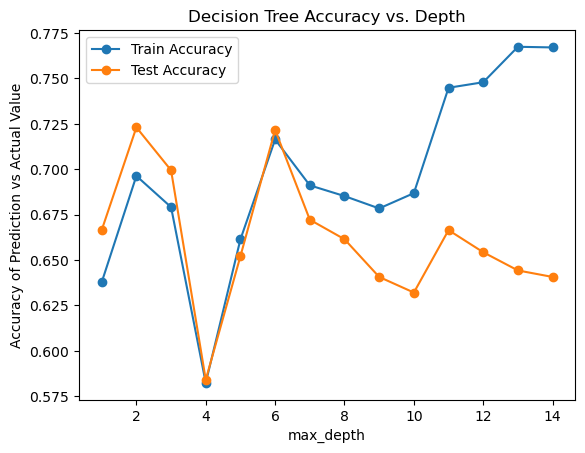

In [478]:
#Plotting to visualize best max_depth when comparing to accuracy
plt.plot(range(1,15), train_acc_list, marker = "o", label = "Train Accuracy")
plt.plot(range(1,15), test_acc_list, marker = "o", label = "Test Accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy of Prediction vs Actual Value")
plt.title("Decision Tree Accuracy vs. Depth")
plt.legend()
#plt.savefig("DecisionTree_AccuracyvsDepth.png", dpi=300) 
plt.show()

In [476]:
from sklearn.metrics import classification_report

#Chosen max_depth = 6
clf_model = DecisionTreeClassifier(class_weight= "balanced", max_depth = 6, random_state = 42)
clf_model.fit(X_train, y_train)

# predic = prediction
train_predic = clf_model.predict(X_train)
test_predic = clf_model.predict(X_test)

print("Train Evaluation:")
print(classification_report(y_train, train_predic))
print("Test Evaluation:") 
print(classification_report(y_test, test_predic))

Train Evaluation:
               precision    recall  f1-score   support

High Severity       0.25      0.55      0.35       770
 Low Severity       0.91      0.74      0.82      4817

     accuracy                           0.72      5587
    macro avg       0.58      0.65      0.58      5587
 weighted avg       0.82      0.72      0.75      5587

Test Evaluation:
               precision    recall  f1-score   support

High Severity       0.20      0.48      0.28       162
 Low Severity       0.92      0.75      0.83      1235

     accuracy                           0.72      1397
    macro avg       0.56      0.61      0.56      1397
 weighted avg       0.83      0.72      0.76      1397



In [477]:
#Getting five random samples predicted wrong:
wrong_samples = X_test[test_predic != y_test].copy() #Creating a copy df
wrong_samples["Actual Severity"] = y_test[test_predic != y_test] #Getting the true severity from the test data
wrong_samples["Predicted Severity"] = test_predic[test_predic != y_test] #Getting the false predicted severity

#5 random samples gotten wrong:
display(wrong_samples.sample(5))
#5 from the first rows:
display(wrong_samples.head(5))

,Route Type_County Route,Route Type_Major Route,Route Type_Municipality/Local Route,Route Type_Private/Bike Route,Weather_CLEAR,Weather_CLOUDY,Weather_COLD/STRONG WEATHER/BAD VISIBILITY,Weather_FOGGY,Weather_RAIN,Weather_SNOW,...,Time of Day_Morning,Time of Day_Night,Week Day_Weekday,Week Day_Weekend,Month_Fall,Month_Spring,Month_Summer,Month_Winter,Actual Severity,Predicted Severity
544,False,True,False,False,True,False,False,0,False,False,...,False,False,True,False,False,False,False,True,Low Severity,High Severity
65,False,True,False,False,True,False,False,0,False,False,...,False,False,False,True,True,False,False,False,Low Severity,High Severity
2083,True,False,False,False,True,False,False,0,False,False,...,True,False,True,False,True,False,False,False,High Severity,Low Severity
1807,False,True,False,False,True,False,False,0,False,False,...,False,False,True,False,False,True,False,False,Low Severity,High Severity
1419,False,True,False,False,False,False,False,0,False,False,...,False,False,False,True,True,False,False,False,Low Severity,High Severity


,Route Type_County Route,Route Type_Major Route,Route Type_Municipality/Local Route,Route Type_Private/Bike Route,Weather_CLEAR,Weather_CLOUDY,Weather_COLD/STRONG WEATHER/BAD VISIBILITY,Weather_FOGGY,Weather_RAIN,Weather_SNOW,...,Time of Day_Morning,Time of Day_Night,Week Day_Weekday,Week Day_Weekend,Month_Fall,Month_Spring,Month_Summer,Month_Winter,Actual Severity,Predicted Severity
2944,False,True,False,False,True,False,False,0,False,False,...,False,False,True,False,False,False,True,False,High Severity,Low Severity
3834,False,False,False,False,True,False,False,0,False,False,...,False,False,True,False,True,False,False,False,Low Severity,High Severity
4020,True,False,False,False,True,False,False,0,False,False,...,True,False,True,False,False,False,True,False,Low Severity,High Severity
3806,True,False,False,False,True,False,False,0,False,False,...,False,False,False,True,True,False,False,False,High Severity,Low Severity
6865,True,False,False,False,True,False,False,0,False,False,...,False,True,True,False,False,True,False,False,Low Severity,High Severity


In [489]:
#Matching it to the original df rows for more readability
wrong_mask = (test_predic != y_test)
wrong_indexs = y_test[wrong_mask].index

wrong_orig = crash_df.loc[wrong_indexz].copy()

wrong_orig["Actual Severity"] = y_test.loc[wrong_indexs].values
wrong_orig["Predicted Severity"] = test_predic[wrong_mask]


In [490]:
wrong_orig.head()

,Route Type,Weather,Surface Condition,Light,Traffic Control,Driver Substance Abuse,Pedestrian Movement,Pedestrian Location,Injury Severity,Safety Equipment,Time of Day,Week Day,Month,Actual Severity,Predicted Severity
2944,Major Route,CLEAR,DRY,DAYLIGHT,No Controls,Unknown,Walking/Riding W/Traffic,On Roadway Not At Crosswalk,High Severity,Helmet,Evening,Weekday,Summer,High Severity,Low Severity
3834,NaN,CLEAR,OTHER/UNKNOWN,DAYLIGHT,No Controls,None Detected,Standing,Other,Low Severity,Unknown,Afternoon,Weekday,Fall,Low Severity,High Severity
4020,County Route,CLEAR,DRY,DAWN,Stop Sign,None Detected,Cross/Enter At Intersection,On Roadway At Crosswalk,Low Severity,Unknown,Morning,Weekday,Summer,Low Severity,High Severity
3806,County Route,CLEAR,DRY,DAYLIGHT,Other/Unknown,None Detected,Other,Midblock Crossing/Travel Lane Other/Median,High Severity,Unknown,Afternoon,Weekend,Fall,High Severity,Low Severity
6865,County Route,CLEAR,DRY,DARK - LIGHTED,No Controls,Unknown,Unknown,Unknown,Low Severity,Unknown,Night,Weekday,Spring,Low Severity,High Severity


In [ ]:
#min_samples_leaf=